# Epoched Decoding Analysis — FL replay & held-out Task (switchable)

One notebook, one `SOURCE` switch (config cell). `fl` replays the training recording (in-sample; the honest metric is the CV-AUC cell); the task sources (`stage2_learning` / `stage2_test` / `stage3`) are leakage-free held-out tests. Only the recording and the marker→label mapping branch on `SOURCE`; the rest is shared. The heavy lifting lives in `analysis_lib` (`context`, `streaming`, `sources`, `metrics`, `plots`), so the cells stay thin. Two cells (stimulus-order diagnostic, offline/online parity) are FL-only and self-skip.

In [66]:
from analysis_lib import context
REPO_ROOT = context.bootstrap()                     # repo-root walk + sys.path
from analysis_lib import streaming, sources, plots, task_labels, metrics
import numpy as np
import matplotlib; matplotlib.use("inline")
import matplotlib.pyplot as plt
import mne; mne.set_log_level("ERROR")
print("repo root:", REPO_ROOT)

repo root: /home/itaip/projects/live-reactivation-decoder


## Knobs

In [67]:
# ── Knobs ────────────────────────────────────────────────────────────────────
PROFILE = "fl_all6_within_logl1_early_rest_C100"

# RECORDING SOURCE:
#   "fl"             replay the FL TRAINING recording (in-sample -> P(t) is a
#                    sanity/behaviour view, NOT a performance number; see CV-AUC).
#   "stage2_learning" held-out task ENCODING (perception; 45 trials, both labels).
#   "stage2_test"     held-out task RETRIEVAL (recall; 45 trials + correctness).
#   "stage3"          held-out task PARTIAL RETRIEVAL (single cued feature; 29).
SOURCE = "fl"

MAX_SECONDS = None          # None = whole recording; a number crops (FL quick-run).
BATCH_SIZE_SAMPLES = 40     # mirror StreamWorker's micro-batch.
LABEL_KEY = "true_label"    # stage3 only: "true_label" | "reported_label".

# Winner-take-all rule for the confusion cell:
#   "weighted_prob" = argmax of each decoder's Gaussian tp-weighted mean P(t)
#                     (WINNER_SIGMA s around its trained tp); "vote" = per-timepoint
#                     argmax majority. Flip to compare metrics.
WINNER_MODE  = "weighted_prob"  # "weighted_prob" | "vote"
WINNER_SIGMA = 0.01
MARKER_GROUPS = None        # FL: pool raw markers into named groups (e.g. colour/scene).
MARKERS_OF_INTEREST = None  # FL: subset of markers; None = every decoder's positive label.

## Build context (profile → settings / artifact / preproc / engine)

In [68]:
IS_FL = SOURCE == "fl"
ctx = context.load_context(PROFILE, root=REPO_ROOT / "debug_snapshots")
dc  = plots.display_config(ctx, marker_groups=MARKER_GROUPS, markers_of_interest=MARKERS_OF_INTEREST)
engine = ctx.engine()
eci = list(ctx.artifact.online_state["eeg_chunk_indices"])

RECORDING_DIR = ctx.recording_dir if IS_FL else (REPO_ROOT / "data" / "split" / "task")
METADATA_DIR  = REPO_ROOT / "data" / "split" / "metadata"
ANCHOR_CODE = {"stage2_learning": task_labels.SHOW_BINDING,
               "stage2_test":     task_labels.REMEMBER_Q,
               "stage3":          task_labels.START_RETRIEVAL}.get(SOURCE)

assert engine.feature_width == ctx.preproc.n_channels
print("SOURCE   :", SOURCE, "|", "in-sample (FL)" if IS_FL else "held-out (task)")
print("profile  :", ctx.profile.name, "| recording:", RECORDING_DIR)
print("decoders :", list(ctx.artifact.models), "| display:", dc.display_markers)

SOURCE   : fl | in-sample (FL)
profile  : fl_all6_within_logl1_early_rest_C100 | recording: /home/itaip/projects/live-reactivation-decoder/data/split/functional_localizer
decoders : ['red decoder', 'green decoder', 'yellow decoder', 'living_room decoder', 'bathroom decoder', 'kitchen decoder'] | display: ['red', 'green', 'yellow', 'living_room', 'bathroom', 'kitchen']


## Cross-validated AUC per decoder — the honest metric

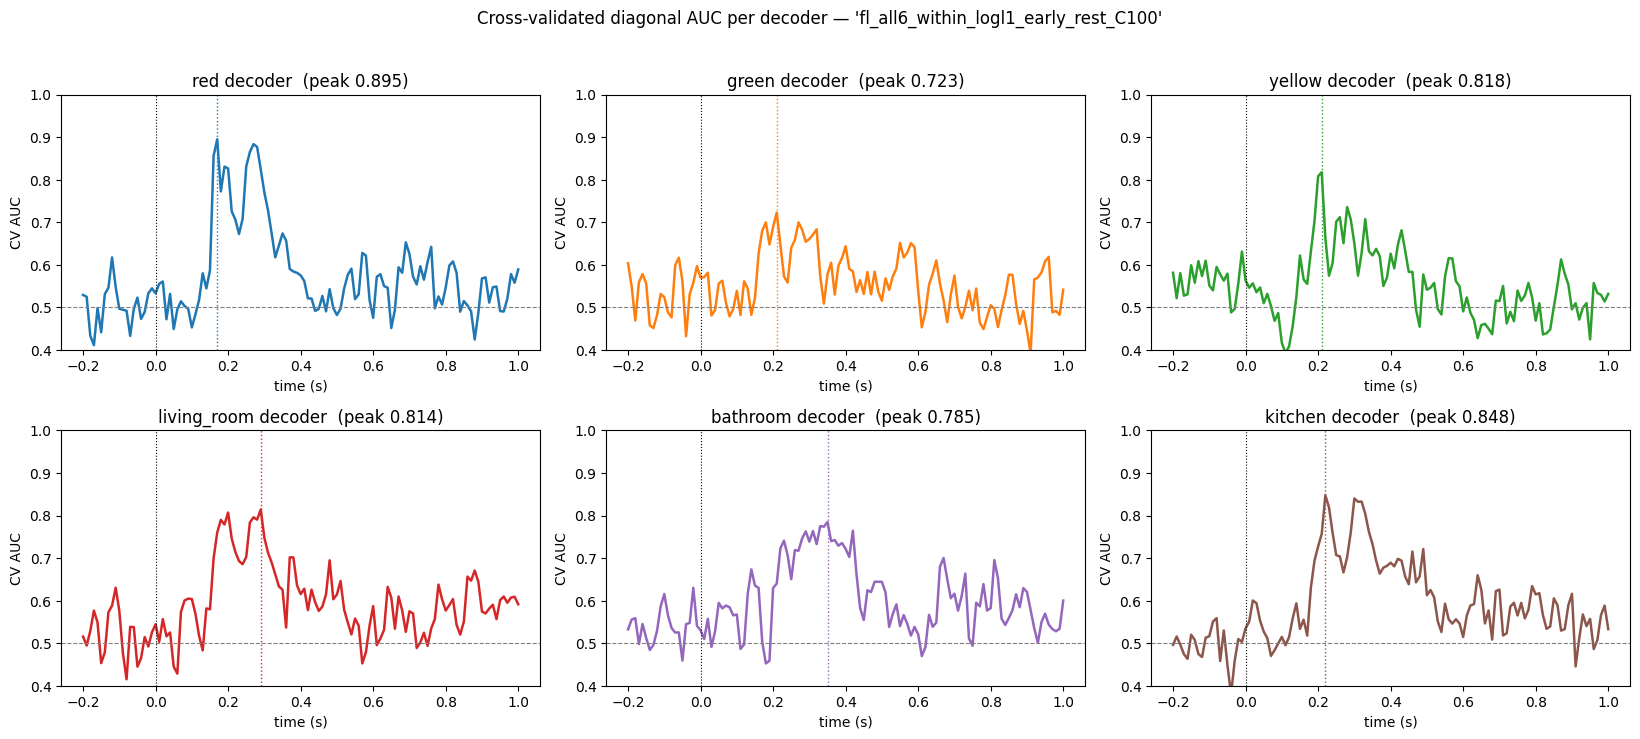

average peak AUC: 0.756 | suggested timepoint: 0.280s


In [69]:
eval_results = plots.cv_auc(ctx)

## Load the recording

In [70]:
raw, eeg, sfreq = streaming.load_recording(RECORDING_DIR, MAX_SECONDS)
n_times, n_fed = eeg.shape
assert max(eci) < n_fed, "channel/EMG alignment mismatch (eeg_chunk_indices vs fed channels)"
print(f"sfreq={sfreq:g} Hz | fed EEG channels={n_fed} | samples={n_times} ({n_times/sfreq:.1f}s)")

sfreq=1000 Hz | fed EEG channels=64 | samples=3267209 (3267.2s)


## Markers → labeled samples (per source)

In [71]:
samples_by_group, trials, info = sources.build_source_samples(
    ctx, raw, sfreq, SOURCE, dc, n_times=n_times, metadata_dir=METADATA_DIR,
    recording_dir=RECORDING_DIR, anchor_code=ANCHOR_CODE, label_key=LABEL_KEY)
print(info)
print("samples per group:", {k: len(v) for k, v in sorted(samples_by_group.items())})

FL markers: {'green': 70, 'red': 70, 'living_room': 70, 'bathroom': 70, 'kitchen': 70, 'yellow': 69}
samples per group: {'bathroom': 70, 'green': 70, 'kitchen': 70, 'living_room': 70, 'red': 70, 'yellow': 69}


## Stimulus-order diagnostic *(FL only)*

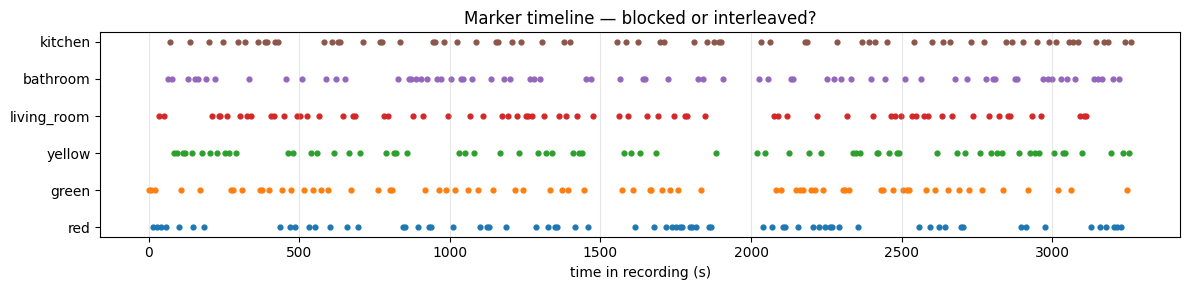

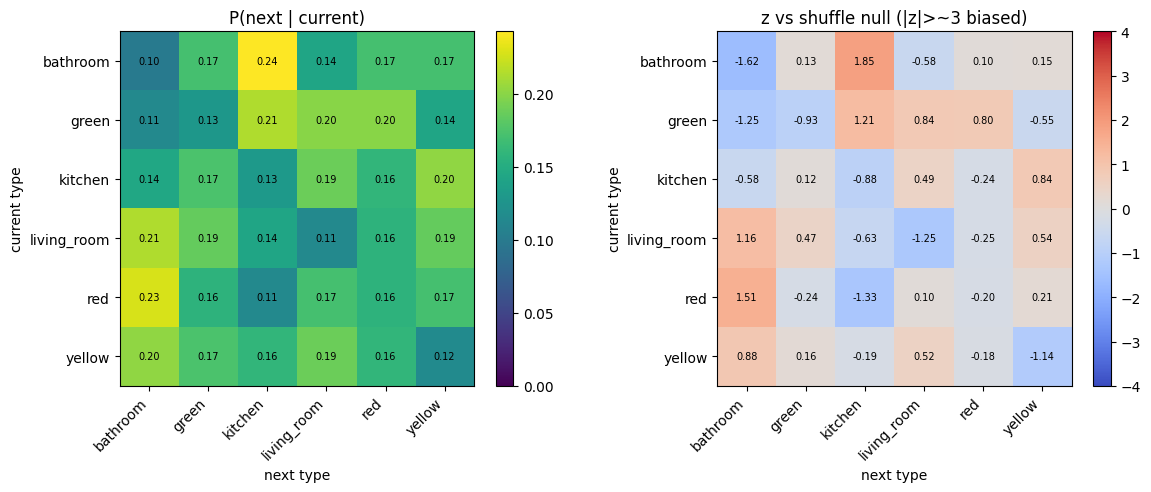

global transition test: shuffle p=0.863 ✓ consistent with random order


In [72]:
if IS_FL:
    plots.fl_marker_diagnostic(ctx, raw, dc)
else:
    print("stimulus-order diagnostic is FL-only — skipped for task sources")

## Replay through the online inference path

In [73]:
features, out_samples, fs_out = streaming.run_online_stream(
    ctx.preproc, eeg, batch_size=BATCH_SIZE_SAMPLES)
preds = engine.predict(features)
print(f"output rows={features.shape[0]} @ {fs_out:g} Hz | tasks={list(preds)}")

output rows=326721 @ 100 Hz | tasks=['red decoder', 'green decoder', 'yellow decoder', 'living_room decoder', 'bathroom decoder', 'kitchen decoder']


## Epoch the probability stream

In [74]:
TMIN, TMAX = ctx.epoch_tmin, ctx.epoch_tmax
t_grid, epoch_stream = streaming.make_epocher(out_samples, sfreq, fs_out, TMIN, TMAX)

# Keep only display groups that actually occur in this recording (drives every view).
dc.display_markers = [m for m in dc.display_markers if m in samples_by_group]
epoched = {t: {g: epoch_stream(prob, sorted(samples_by_group.get(g, [])))
               for g in dc.display_markers}
           for t, prob in preds.items()}
print("epochs per group:", {g: epoched[next(iter(preds))][g].shape[0] for g in dc.display_markers})

epochs per group: {'red': 70, 'green': 70, 'yellow': 69, 'living_room': 70, 'bathroom': 70, 'kitchen': 70}


## Per-decoder response to its own positive group

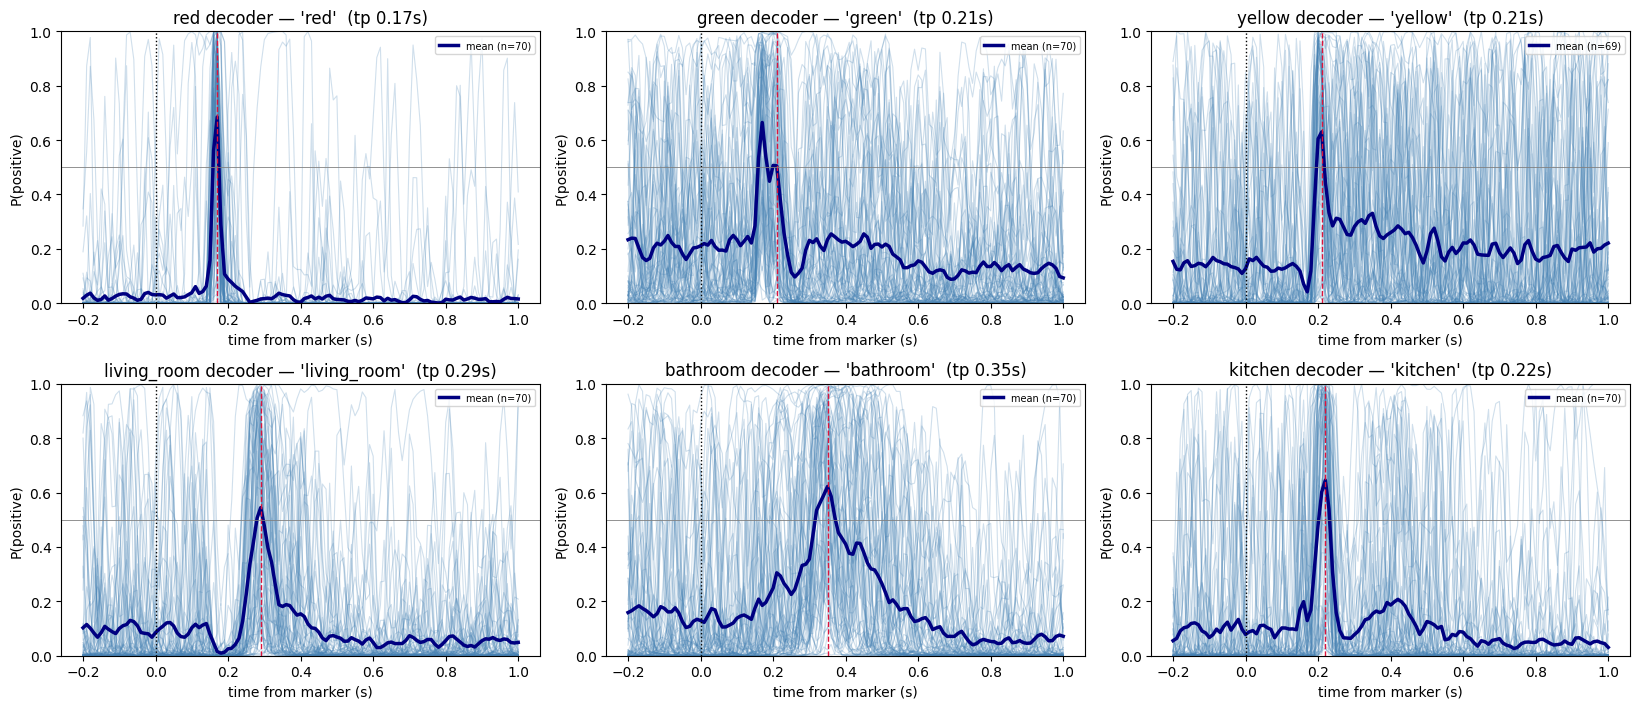

In [75]:
plots.per_decoder(ctx, dc, epoched, t_grid, preds)

## Selectivity — every group overlaid per decoder

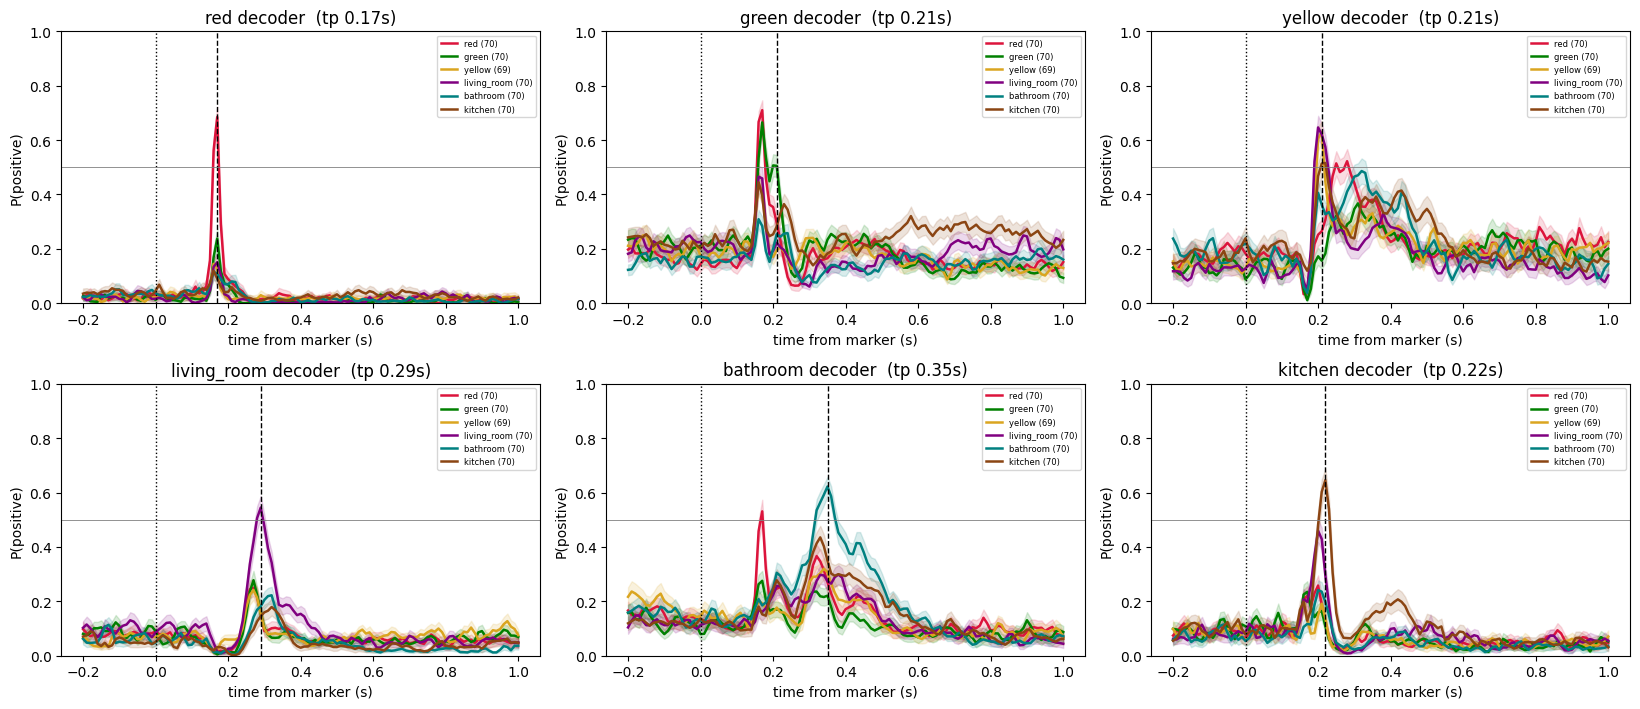

In [76]:
plots.selectivity(ctx, dc, epoched, t_grid, preds)

## Decoder competition per group — raw vs baseline-corrected

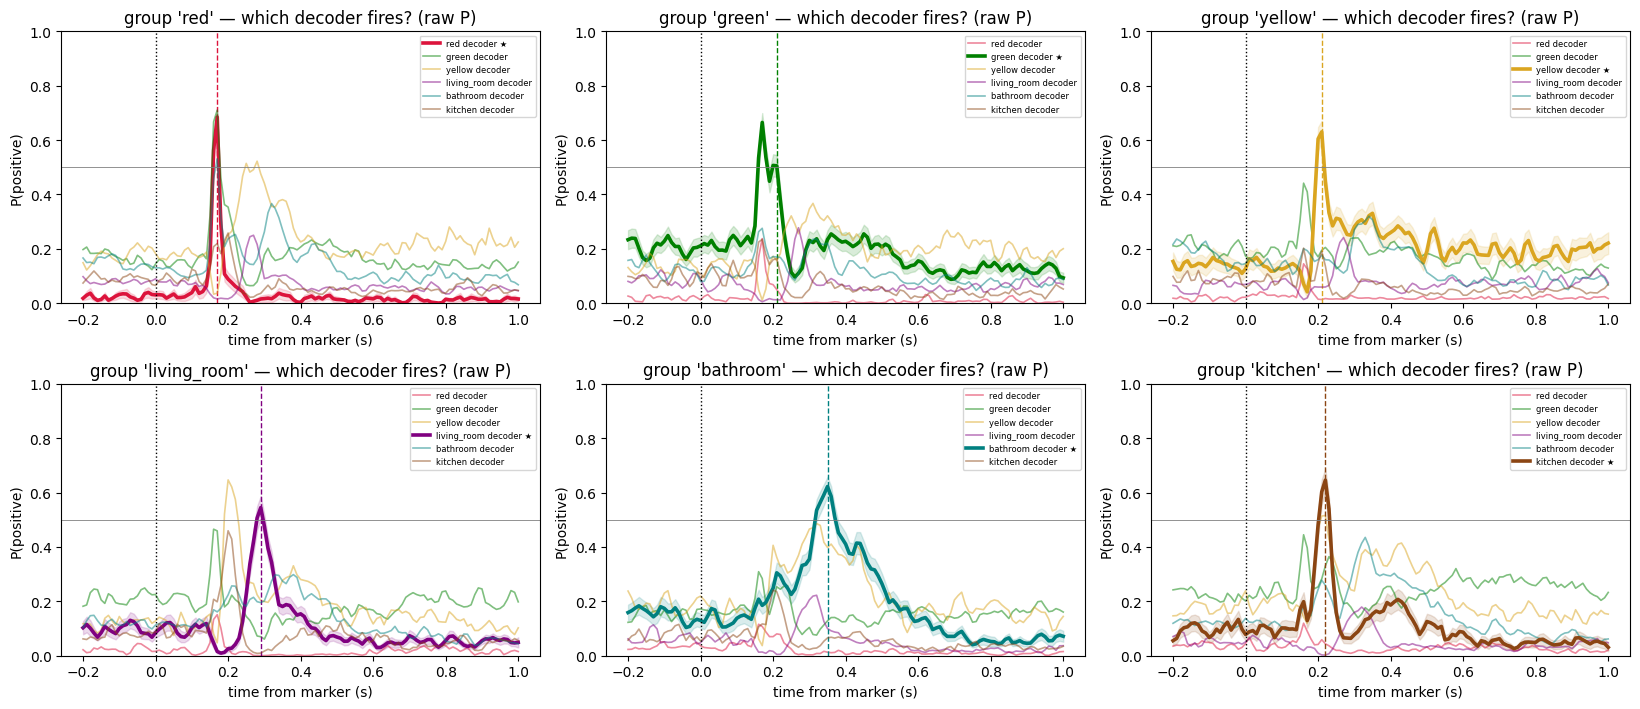

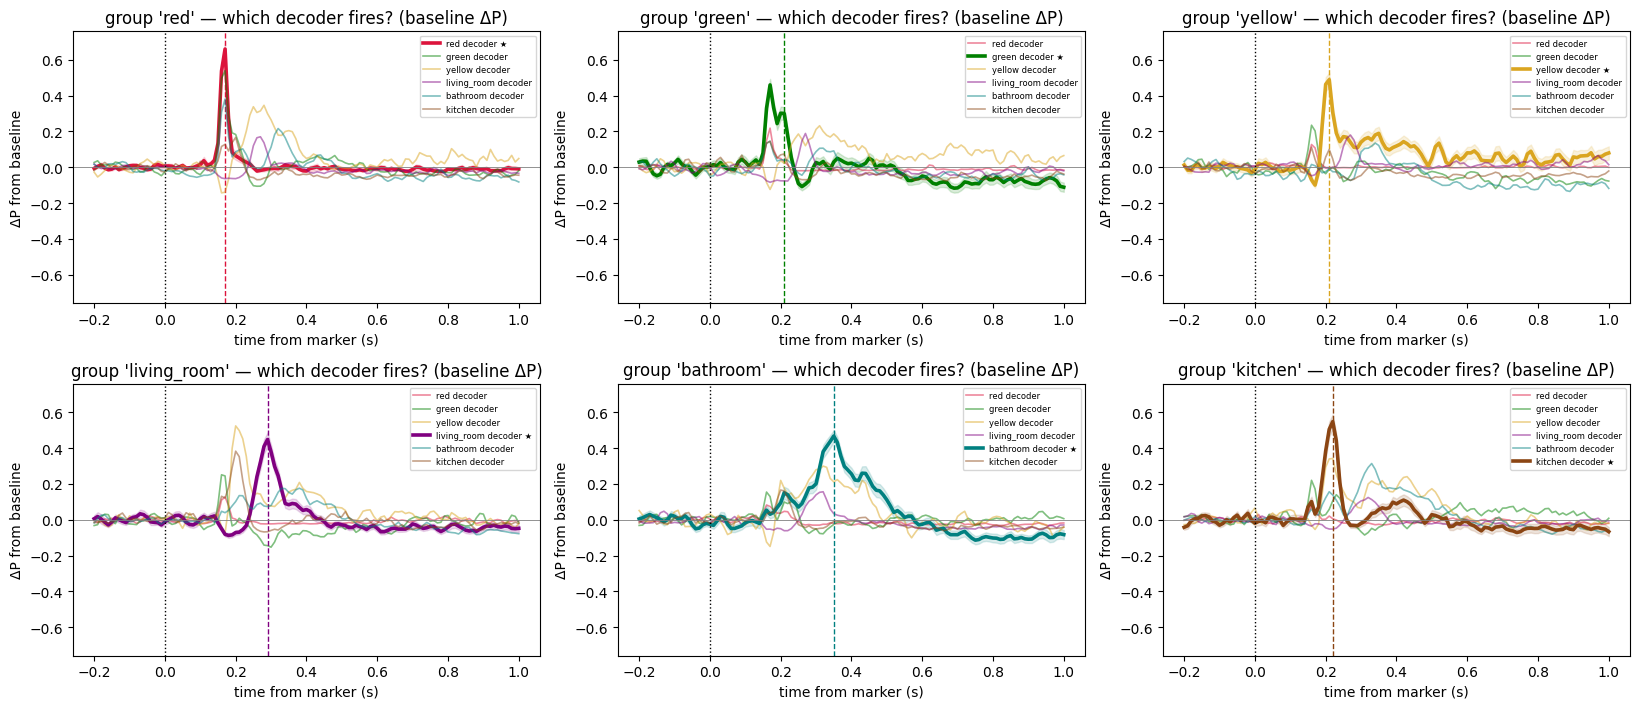

In [77]:
plots.competition(ctx, dc, epoched, t_grid, preds)

## Winner confusion + label permutation — raw vs baseline-corrected

[weighted_prob, raw] red/green/yellow: accuracy=0.656 (chance 0.33) | macro precision 0.668, recall 0.656
[weighted_prob, raw] living_room/bathroom/kitchen: accuracy=0.633 (chance 0.33) | macro precision 0.646, recall 0.633


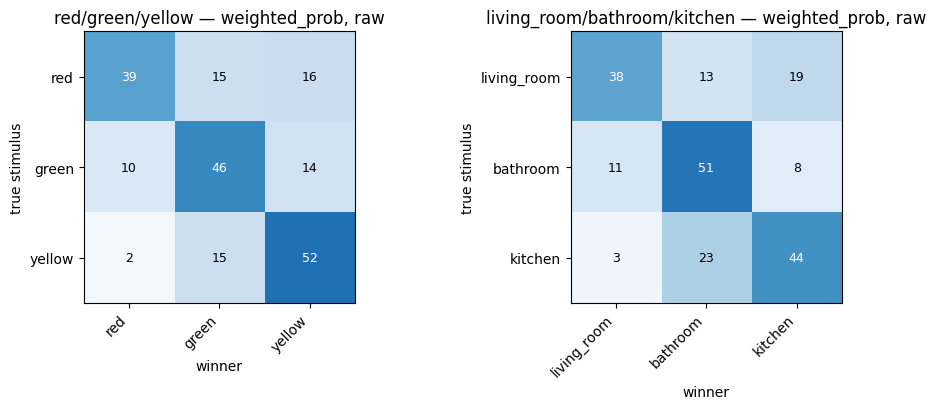

[weighted_prob, baseline ΔP] red/green/yellow: accuracy=0.718 (chance 0.33) | macro precision 0.723, recall 0.718
[weighted_prob, baseline ΔP] living_room/bathroom/kitchen: accuracy=0.676 (chance 0.33) | macro precision 0.685, recall 0.676


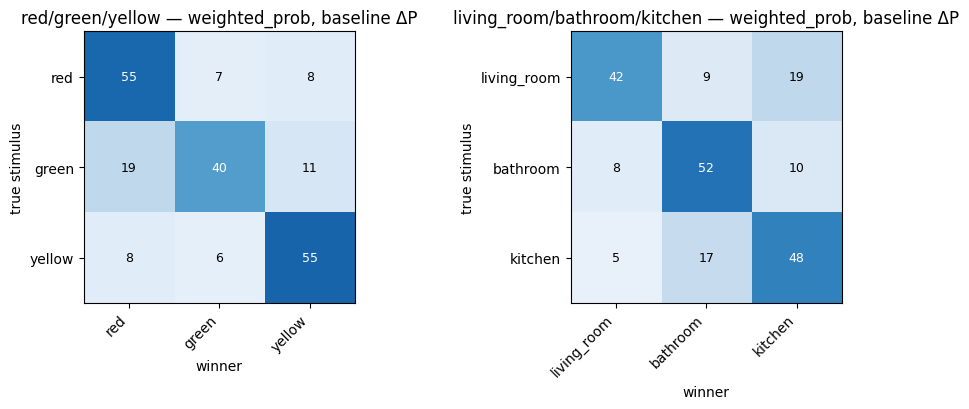

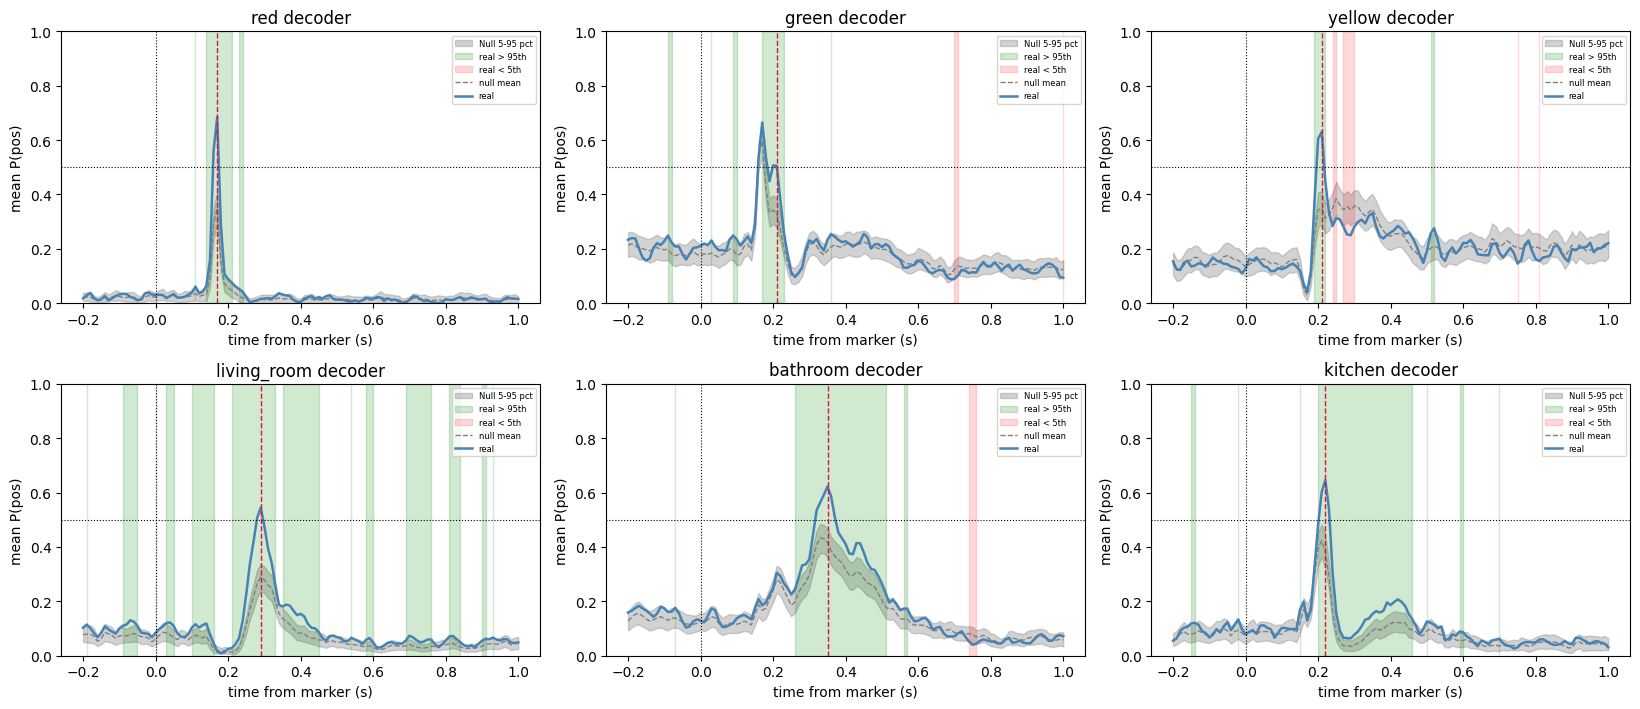

In [78]:
plots.confusion_and_perm(ctx, dc, epoched, t_grid, preds,
                         ctx.settings.get_decoder_settings()["tasks"],
                         mode=WINNER_MODE, sigma=WINNER_SIGMA)

## Offline vs online parity *(FL only)*

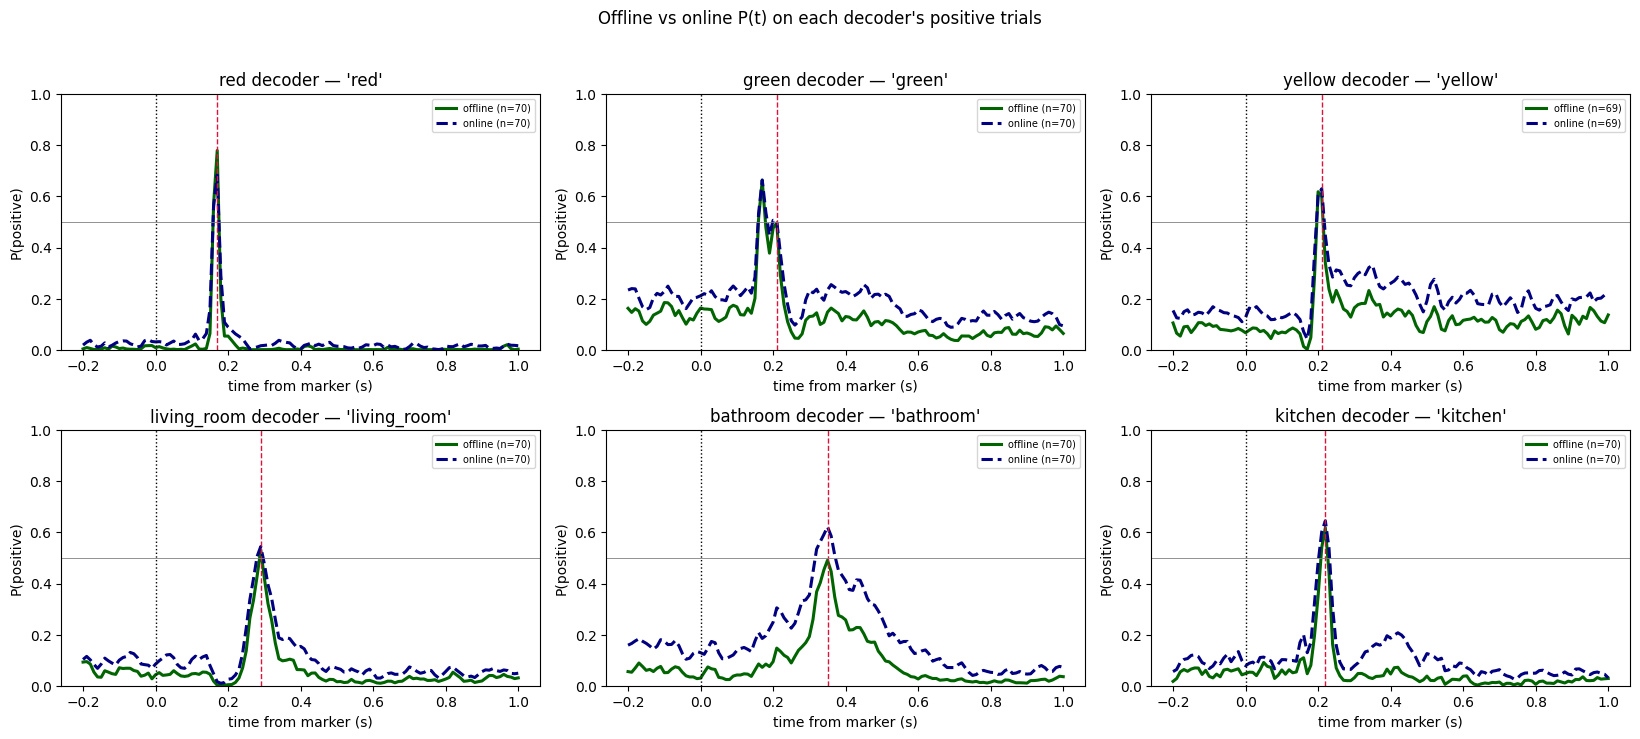

In [79]:
if IS_FL:
    plots.parity(ctx, dc, epoched, t_grid, preds)
else:
    print("offline/online parity is FL-only — skipped for task sources")

## Summary table — each decoder at its own trained timepoint

In [80]:
plots.timepoint_table(ctx, dc, epoched, t_grid, preds)

task                     tp(s)         red       green      yellow living_room    bathroom     kitchen
------------------------------------------------------------------------------------------------------
red decoder               0.17       0.685       0.238       0.126       0.151       0.108       0.090
green decoder             0.21       0.295       0.505       0.195       0.223       0.254       0.283
yellow decoder            0.21       0.265       0.156       0.630       0.621       0.362       0.514
living_room decoder       0.29       0.156       0.155       0.154       0.545       0.181       0.146
bathroom decoder          0.35       0.271       0.221       0.307       0.275       0.622       0.350
kitchen decoder           0.22       0.124       0.109       0.137       0.296       0.198       0.646


## Save run summary

In [81]:
out = context.save_run_summary(ctx, dc, epoched, t_grid, preds, eval_results,
                              source=SOURCE, max_seconds=MAX_SECONDS)
print("saved", out)

saved /home/itaip/projects/live-reactivation-decoder/debug_snapshots/fl_all6_within_logl1_early_rest_C100/live_summary.joblib
